# Задание 5. Чистка данных, кодирование, масштабирование и Random Forest

Что нужно сделать:
- **Часть 1** — на датасете «Прогнозирование типа погоды» предсказать целевой столбец `Weather Type`:
  очистить данные от выбросов, дубликатов и пропусков; привести категориальные признаки к числовому виду;
  оценить важность признаков через `feature_importances_` и отобрать важнейшие; выполнить предобработку `X`
  скейлером **без утечки** (сначала train-test-split, потом параметры преобразования по обучающей выборке,
  потом применение к обеим); обучить несколько моделей `RandomForestClassifier` — глубина от 3 до 5 на
  количество деревьев [5, 10, 20]; построить матрицу ошибок для каждой модели и сравнить их по Accuracy,
  Precision, Recall; нарисовать карту границ классификации; сравнить одну и ту же модель при трёх способах
  предобработки — `StandardScaler`, `MinMaxScaler`, `Normalizer`;
- **Часть 2** — на «грязном» датасете продаж кафе выполнить только предобработку, без обучения модели:
  привести категориальные значения к числовому виду, очистить/восполнить пропуски, убрать выбросы
  и дубликаты, привести даты к единому формату.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder,
                                   StandardScaler, MinMaxScaler, Normalizer)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix)

np.random.seed(42)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Часть 1. Прогнозирование типа погоды (Random Forest)

### Шаг 1. Загружаем данные и смотрим на них

Целевой столбец — `Weather Type` (4 класса). Категориальные признаки — `Cloud Cover`, `Season`, `Location`,
остальные восемь столбцов числовые.

In [2]:
df = pd.read_csv("weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,13200.0,19.127576,17.386327,-25.00,4.0,21.00,31.0000,109.00
Humidity,13200.0,68.710833,20.194248,20.00,57.0,70.00,84.0000,109.00
Wind Speed,13200.0,9.832197,6.908704,0.00,5.0,9.00,13.5000,48.50
Precipitation (%),13200.0,53.644394,31.946541,0.00,19.0,58.00,82.0000,109.00
Atmospheric Pressure,13200.0,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
UV Index,13200.0,4.005758,3.856600,0.00,1.0,3.00,7.0000,14.00
Visibility (km),13200.0,5.462917,3.371499,0.00,3.0,5.00,7.5000,20.00


In [5]:
# пропуски и полные дубликаты строк
print("пропусков всего:", df.isnull().sum().sum())
print("полных дубликатов:", df.duplicated().sum())

пропусков всего: 0
полных дубликатов: 0


In [6]:
# баланс классов и состав категориальных столбцов
print(df["Weather Type"].value_counts())
print()
for col in ["Cloud Cover", "Season", "Location"]:
    print(col, "->", dict(df[col].value_counts()))

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

Cloud Cover -> {'overcast': np.int64(6090), 'partly cloudy': np.int64(4560), 'clear': np.int64(2139), 'cloudy': np.int64(411)}
Season -> {'Winter': np.int64(5610), 'Spring': np.int64(2598), 'Autumn': np.int64(2500), 'Summer': np.int64(2492)}
Location -> {'inland': np.int64(4816), 'mountain': np.int64(4813), 'coastal': np.int64(3571)}


Пропусков и полных дубликатов в датасете нет, классы идеально сбалансированы — по 3300 наблюдений на каждый
из четырёх типов погоды, то есть случайное угадывание дало бы accuracy 0.25.

Зато в `describe()` видны **физически невозможные значения**: влажность до 109% и вероятность осадков до 109%
(это проценты, максимум 100), температура до +109 °C (мировой рекорд около +57 °C) и атмосферное давление
от 800 до 1199 гПа (реальные рекорды — примерно 870 и 1084 гПа). Это явный мусор, с ним и будем работать
на следующем шаге.

### Шаг 2. Чистим данные от выбросов, дубликатов и пропусков

Пропусков нет, дубликаты на всякий случай убираем `drop_duplicates()`. Выбросы ищем **не** по правилу
1.5·IQR, а по границам физического смысла: IQR формально помечает выбросами, например, видимость 20 км
и ветер 30 км/ч, а это совершенно нормальная погода, и удалять такие строки было бы неправильно. Поэтому
задаём для четырёх столбцов разумные границы и выбрасываем всё, что за них выходит.

In [7]:
data = df.drop_duplicates()

# границы физического смысла: проценты не больше 100, температура и давление — по мировым рекордам
bounds = {"Humidity": (0, 100),
          "Precipitation (%)": (0, 100),
          "Temperature": (-40, 60),
          "Atmospheric Pressure": (900, 1100)}

for col, (lo, hi) in bounds.items():
    print(col, "— значений вне границ:", ((data[col] < lo) | (data[col] > hi)).sum())

Humidity — значений вне границ: 416
Precipitation (%) — значений вне границ: 392
Temperature — значений вне границ: 207
Atmospheric Pressure — значений вне границ: 612


In [8]:
mask = pd.Series(True, index=data.index)
for col, (lo, hi) in bounds.items():
    mask = mask & data[col].between(lo, hi)

data = data[mask]

print("было строк:", len(df), " осталось:", len(data),
      " удалено:", len(df) - len(data), f"({(len(df) - len(data)) / len(df):.1%})")
print()
print(data["Weather Type"].value_counts())

было строк: 13200  осталось: 11748  удалено: 1452 (11.0%)

Weather Type
Snowy     2981
Cloudy    2949
Rainy     2942
Sunny     2876
Name: count, dtype: int64


In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,11748.0,18.323800,15.497401,-24.00,4.0000,21.00,30.00,60.00
Humidity,11748.0,67.839888,19.061120,20.00,57.0000,69.00,82.00,100.00
Wind Speed,11748.0,9.444161,6.394516,0.00,5.0000,8.50,13.50,48.50
Precipitation (%),11748.0,50.682755,31.165197,0.00,18.0000,54.00,79.00,100.00
Atmospheric Pressure,11748.0,1005.814996,17.740737,900.49,995.2375,1007.48,1016.34,1099.65
UV Index,11748.0,3.615169,3.594108,0.00,1.0000,2.00,6.00,14.00
Visibility (km),11748.0,5.321416,3.048002,0.00,3.0000,5.00,7.50,20.00


Удалили 1452 строки (11% выборки) — часть строк была испорчена сразу по нескольким столбцам, поэтому
сумма по столбцам больше итога. Баланс классов при этом почти не пострадал (2876–2981 на класс), значит
мусор был раскидан по датасету случайно и мы не выкинули целиком какой-то один тип погоды. В `describe()`
после чистки все столбцы лежат в физически осмысленных пределах.

### Шаг 3. Приводим категориальные значения к числовому виду

Из трёх вариантов (`LabelEncoder` / `OrdinalEncoder` / `get_dummies`) берём **`OrdinalEncoder`** для признаков
и `LabelEncoder` для целевого столбца. Почему так:

- деревья делят выборку по порогам вида «признак < значения», им не нужны отдельные бинарные столбцы,
  а `get_dummies` раздул бы матрицу на 11 столбцов и размазал важность одного признака по всем его
  «дамми», из-за чего шаг с feature importance стало бы труднее читать;
- `OrdinalEncoder`, в отличие от `LabelEncoder`, позволяет задать порядок категорий руками. Для
  `Cloud Cover` порядок осмысленный — от `clear` к `overcast` по возрастанию облачности, и такая нумерация
  дереву прямо помогает. Для `Season` и `Location` порядок условный, но деревьям это не мешает.

In [10]:
cat_cols = ["Cloud Cover", "Season", "Location"]

enc = OrdinalEncoder(categories=[["clear", "partly cloudy", "cloudy", "overcast"],
                                 ["Winter", "Spring", "Summer", "Autumn"],
                                 ["inland", "mountain", "coastal"]])
data[cat_cols] = enc.fit_transform(data[cat_cols])

# целевой столбец кодируем отдельно
le = LabelEncoder()
y = le.fit_transform(data["Weather Type"])
X = data.drop("Weather Type", axis=1)

class_names = list(le.classes_)
print("классы:", dict(zip(class_names, range(len(class_names)))))
X.head()

классы: {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,14.0,73,9.5,82.0,1.0,1010.82,2,0.0,3.5,0.0
1,39.0,96,8.5,71.0,1.0,1011.43,7,1.0,10.0,0.0
2,30.0,64,7.0,16.0,0.0,1018.72,5,1.0,5.5,1.0
3,38.0,83,1.5,82.0,0.0,1026.25,7,1.0,1.0,2.0
4,27.0,74,17.0,66.0,3.0,990.67,1,0.0,2.5,1.0


Все столбцы стали числовыми. Кодирование категорий — это просто переименование значений, никакой статистики
по выборке здесь не считается, поэтому его можно делать до разбиения: утечки информации из теста не будет.

### Шаг 4. Разбиение train-test-split

Разбиение делаем **до** всего, что считает какие-либо параметры по данным — и до отбора признаков,
и до масштабирования. Берём 70% / 30% со стратификацией по классу.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (8223, 10)  тестовая: (3525, 10)


### Шаг 5. Важность признаков и отбор важнейших

Обучаем «оценочный» лес из 100 деревьев **только на обучающей выборке** и смотрим `feature_importances_`.
Дереву масштаб признаков безразличен, поэтому здесь работаем с необработанными значениями.

In [12]:
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
rf_all.fit(X_train, y_train)

importances = pd.Series(rf_all.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.round(4)

Temperature             0.2315
Precipitation (%)       0.1795
UV Index                0.1764
Visibility (km)         0.1338
Atmospheric Pressure    0.0873
Cloud Cover             0.0641
Humidity                0.0508
Season                  0.0403
Wind Speed              0.0250
Location                0.0111
dtype: float64

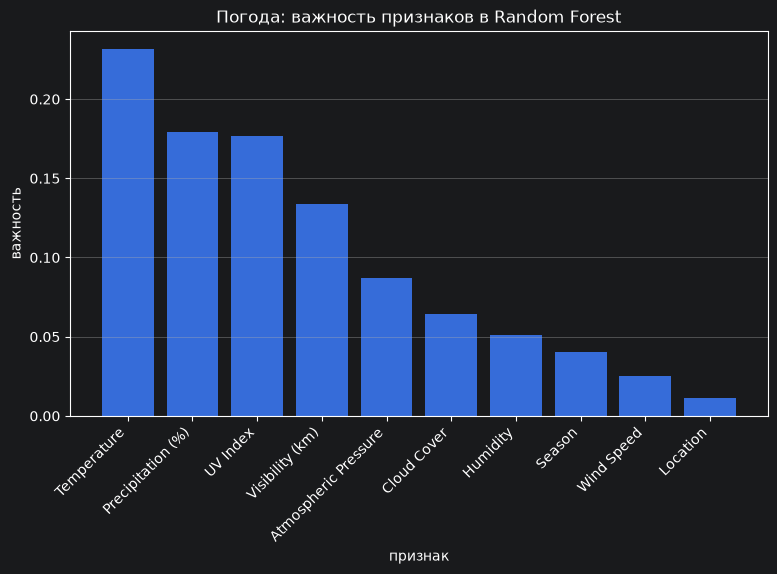

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("признак")
plt.ylabel("важность")
plt.title("Погода: важность признаков в Random Forest")
plt.grid(True, axis="y")
plt.show()

In [14]:
# оставляем признаки с важностью не меньше 0.05
top_features = importances[importances >= 0.05].index.tolist()

print("отобрано признаков:", len(top_features), "из", X.shape[1])
print(top_features)
print("их суммарная важность:", round(importances[top_features].sum(), 3))

отобрано признаков: 7 из 10
['Temperature', 'Precipitation (%)', 'UV Index', 'Visibility (km)', 'Atmospheric Pressure', 'Cloud Cover', 'Humidity']
их суммарная важность: 0.924


In [15]:
# дальше работаем только с отобранным подмножеством
X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]
X_train_sel.head()

,Temperature,Precipitation (%),UV Index,Visibility (km),Atmospheric Pressure,Cloud Cover,Humidity
3376,38.0,14.0,10,6.5,1017.61,0.0,43
1604,2.0,65.0,1,1.0,980.94,3.0,88
8663,22.0,92.0,1,1.5,1008.56,1.0,91
3709,22.0,53.0,3,5.0,1016.33,3.0,68
10488,38.0,81.0,14,1.0,1007.17,1.0,73


Важность распределилась неравномерно: `Temperature` (0.23), `Precipitation (%)` (0.18), `UV Index` (0.18)
и `Visibility (km)` (0.13) вместе дают больше 70% — и это логично, тип погоды в первую очередь и есть
комбинация «тепло/холодно», «есть осадки/нет», «светит солнце/нет». Хвост списка — `Season` (0.04),
`Wind Speed` (0.03) и `Location` (0.01): сезон дублирует температуру, а от места и силы ветра тип погоды
почти не зависит.

По порогу 0.05 остаётся **7 признаков из 10**, в которых собрано 92% всей важности. Три отброшенных
признака дальше не используем.

### Шаг 6. Предобработка X скейлером — в правильном порядке

Условие требует строгой последовательности, иначе будет утечка информации из теста в обучение:

1. разбиение train-test-split — уже сделано на шаге 4;
2. **параметры преобразования считаем только по обучающей выборке** — `scaler.fit(X_train_sel)`;
3. этими же параметрами преобразуем и обучающую, и тестовую выборки — два раза `transform`.

Ключевой момент: на тестовой выборке `fit` / `fit_transform` не вызывается ни разу.

In [16]:
scaler = StandardScaler()
scaler.fit(X_train_sel)                       # параметры считаем ТОЛЬКО по обучающей выборке

X_train_sc = scaler.transform(X_train_sel)    # применяем к обучающей
X_test_sc = scaler.transform(X_test_sel)      # и те же параметры — к тестовой

print("средние, посчитанные по обучающей выборке:")
print(pd.Series(scaler.mean_, index=top_features).round(2))

средние, посчитанные по обучающей выборке:
Temperature               18.29
Precipitation (%)         50.66
UV Index                   3.63
Visibility (km)            5.32
Atmospheric Pressure    1005.78
Cloud Cover                1.79
Humidity                  67.92
dtype: float64


In [17]:
# проверка: у обучающей выборки среднее 0 и std 1, у тестовой — близко, но не ровно,
# и это правильно, потому что её параметрами преобразования никто не подгонял
print("train: mean =", X_train_sc.mean().round(6), " std =", X_train_sc.std().round(4))
print("test:  mean =", X_test_sc.mean().round(4), " std =", X_test_sc.std().round(4))

train: mean = -0.0  std = 1.0
test:  mean = -0.0006  std = 0.9907


Среднее по обучающей выборке ровно 0 и std ровно 1, а по тестовой — -0.0006 при std 0.9907. Именно такая
небольшая «неидеальность» теста и означает, что утечки нет: тест преобразован чужими параметрами, как и
будут преобразовываться реальные новые данные.

### Шаг 7. Девять моделей Random Forest: глубина 3–5 × деревья [5, 10, 20]

Для каждой модели считаем Accuracy, Precision и Recall. Классов четыре, поэтому precision и recall
берём с `average="macro"` — это среднее по классам без учёта их размера (здесь классы сбалансированы,
так что macro-усреднение честное).

In [18]:
rows = []
conf_matrices = {}

for depth in [3, 4, 5]:
    for n_trees in [5, 10, 20]:
        model = RandomForestClassifier(max_depth=depth, n_estimators=n_trees, random_state=42)
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)

        rows.append({
            "max_depth": depth,
            "n_estimators": n_trees,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, average="macro"),
            "Recall": recall_score(y_test, pred, average="macro"),
        })
        conf_matrices[(depth, n_trees)] = confusion_matrix(y_test, pred)

res = pd.DataFrame(rows)
res.round(4)

,max_depth,n_estimators,Accuracy,Precision,Recall
0,3,5,0.9342,0.9378,0.9339
1,3,10,0.9382,0.9407,0.9379
2,3,20,0.9379,0.9413,0.9377
3,4,5,0.9450,0.9464,0.9450
4,4,10,0.9512,0.9514,0.9512
5,4,20,0.9521,0.9523,0.9521
6,5,5,0.9478,0.9482,0.9478
7,5,10,0.9532,0.9537,0.9532
8,5,20,0.9509,0.9512,0.9510


In [19]:
# та же таблица компактно: accuracy по глубине и числу деревьев
res.pivot(index="max_depth", columns="n_estimators", values="Accuracy").round(4)

n_estimators,5,10,20
max_depth,,,
3,0.9342,0.9382,0.9379
4,0.9450,0.9512,0.9521
5,0.9478,0.9532,0.9509


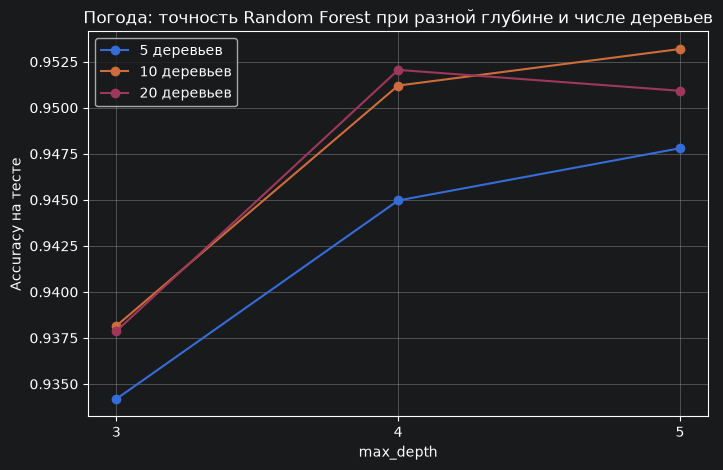

In [20]:
plt.figure(figsize=(8, 5))
for n_trees in [5, 10, 20]:
    part = res[res["n_estimators"] == n_trees]
    plt.plot(part["max_depth"], part["Accuracy"], marker="o", label=f"{n_trees} деревьев")

plt.xticks([3, 4, 5])
plt.xlabel("max_depth")
plt.ylabel("Accuracy на тесте")
plt.title("Погода: точность Random Forest при разной глубине и числе деревьев")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
print(res.sort_values("Accuracy", ascending=False).head(3).round(4))

   max_depth  n_estimators  Accuracy  Precision  Recall
7          5            10    0.9532     0.9537  0.9532
5          4            20    0.9521     0.9523  0.9521
4          4            10    0.9512     0.9514  0.9512


Все девять моделей дают accuracy 0.934–0.953 против 0.25 у случайного угадывания — задача решается легко.
Глубина влияет сильнее числа деревьев: переход с 3 на 4 уровня добавляет сразу около 1.3 процентного пункта
(0.938 → 0.952 при 20 деревьях), а с 4 на 5 уже почти ничего не меняет. Число деревьев тоже помогает,
но только на первом шаге: с 5 до 10 деревьев accuracy растёт на 0.4–0.6 п.п., а с 10 до 20 колеблется
в пределах ±0.2 п.п., то есть уже упирается в шум. Precision и Recall везде идут вплотную к Accuracy —
следствие того, что классы сбалансированы и модель не перекошена ни в одну сторону.

Лучшая модель — **`max_depth = 5`, `n_estimators = 10`**, Accuracy 0.953.

### Шаг 8. Матрицы ошибок для каждой из девяти моделей

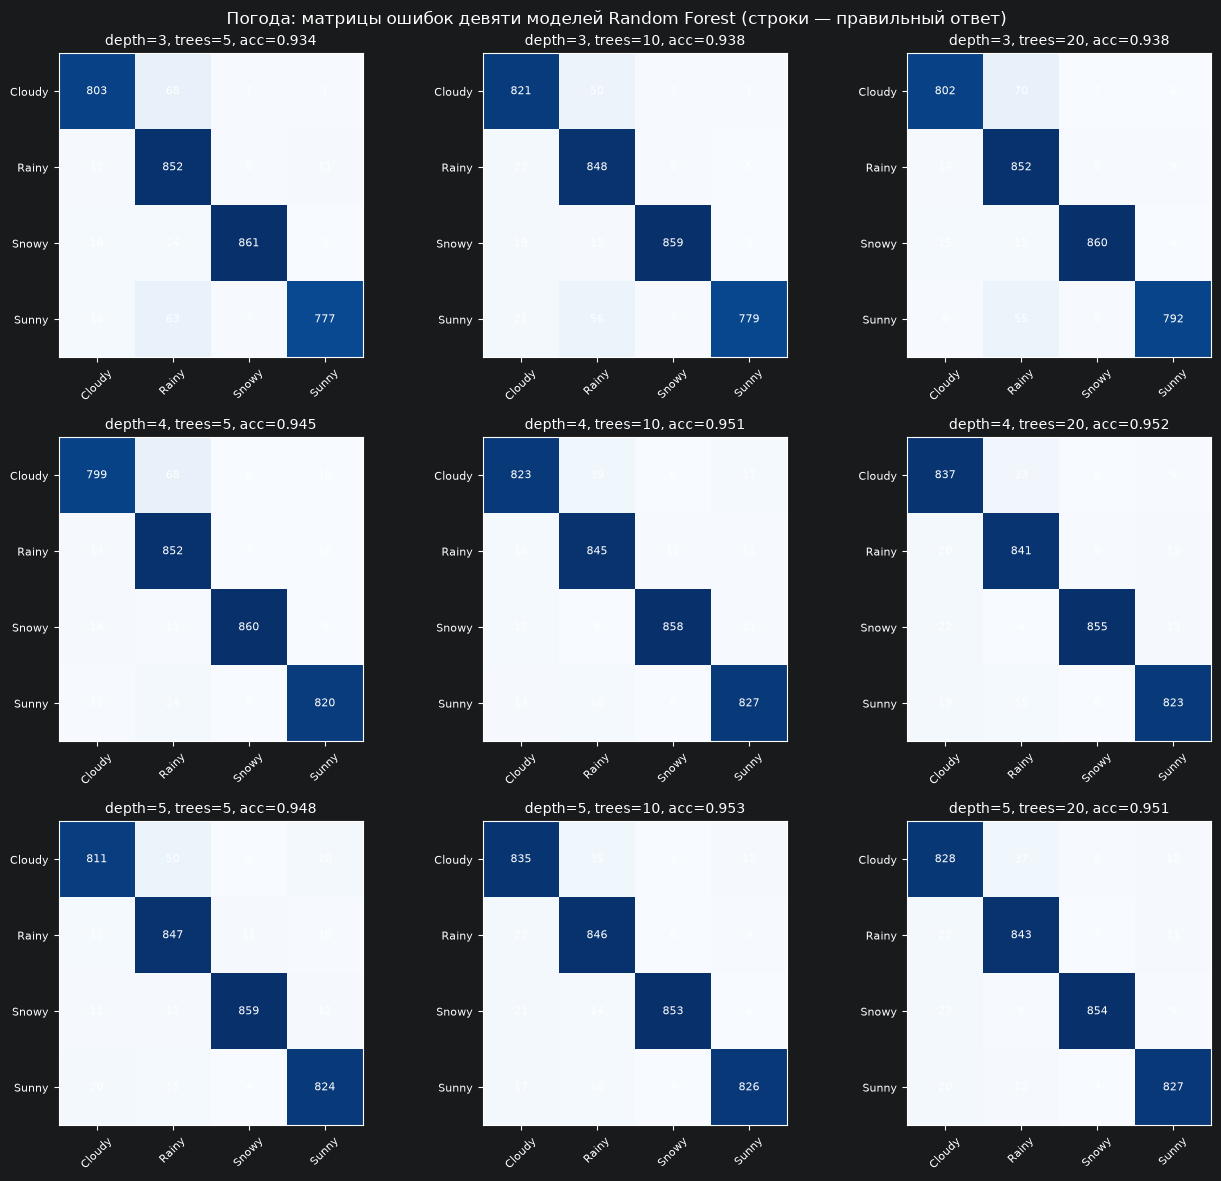

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(13, 12))

for i, depth in enumerate([3, 4, 5]):
    for j, n_trees in enumerate([5, 10, 20]):
        ax = axes[i, j]
        cm = conf_matrices[(depth, n_trees)]
        ax.imshow(cm, cmap="Blues")

        # подписываем числа в клетках
        for a in range(len(class_names)):
            for b in range(len(class_names)):
                ax.text(b, a, cm[a, b], ha="center", va="center", fontsize=8)

        acc = res[(res["max_depth"] == depth) & (res["n_estimators"] == n_trees)]["Accuracy"].iloc[0]
        ax.set_title(f"depth={depth}, trees={n_trees}, acc={acc:.3f}", fontsize=10)
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, fontsize=8)
        ax.set_yticks(range(len(class_names)))
        ax.set_yticklabels(class_names, fontsize=8)

fig.suptitle("Погода: матрицы ошибок девяти моделей Random Forest (строки — правильный ответ)")
fig.tight_layout()
plt.show()

In [23]:
# матрица ошибок лучшей модели крупно, в виде таблицы
best_cm = conf_matrices[(5, 10)]
pd.DataFrame(best_cm, index=class_names, columns=class_names)

,Cloudy,Rainy,Snowy,Sunny
Cloudy,835,35,3,12
Rainy,22,846,6,9
Snowy,21,14,853,6
Sunny,17,16,4,826


Все девять матриц выглядят одинаково по структуре: жирная диагональ и одна повторяющаяся ошибка —
путаница между `Cloudy` и `Rainy` (в лучшей модели 35 облачных дней записаны в дождливые и 22 дождливых
в облачные, это почти половина всех ошибок). Дальше по частоте идёт пара `Cloudy` / `Sunny`. Это
содержательно понятно: дождь без облаков не идёт, и по одним только числовым замерам «пасмурно» и
«дождливо» действительно похожи. А вот `Snowy` почти не путается ни с чем — низкая температура отделяет
снег от остальных классов однозначно.

У самых мелких моделей (depth = 3) заметен перекос: класс `Sunny` угадывается хуже остальных
(777 из 863 при 5 деревьях), потому что трёх уровней не хватает, чтобы отделить его от `Cloudy`.
С ростом глубины перекос выравнивается.

### Шаг 9. Карта границ классификации

Карту рисуем для двух самых важных признаков — `Temperature` и `Precipitation (%)`. На них обучаем
отдельную модель (иначе на плоскости нечего было бы рисовать), берём лучшую конфигурацию
`max_depth = 5`, `n_estimators = 20`, покрываем плоскость сеткой `np.meshgrid` и прогоняем её через модель.

In [24]:
f1, f2 = top_features[0], top_features[1]
print("признаки для карты:", f1, "и", f2)

X2 = X[[f1, f2]]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y)

model2 = RandomForestClassifier(max_depth=5, n_estimators=20, random_state=42)
model2.fit(X2_train, y2_train)

print("accuracy только на двух признаках =", round(accuracy_score(y2_test, model2.predict(X2_test)), 4))

признаки для карты: Temperature и Precipitation (%)
accuracy только на двух признаках = 0.8982


In [25]:
# сетка по плоскости двух признаков
x_min, x_max = X2[f1].min() - 2, X2[f1].max() + 2
y_min, y_max = X2[f2].min() - 2, X2[f2].max() + 2

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.3),
                     np.arange(y_min, y_max, 0.5))

grid = pd.DataFrame({f1: xx.ravel(), f2: yy.ravel()})
zz = model2.predict(grid).reshape(xx.shape)

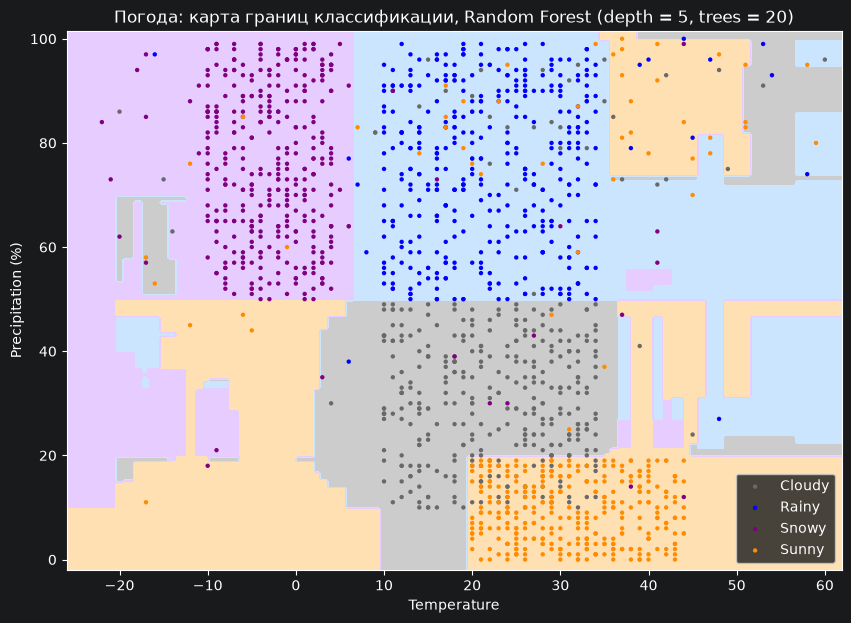

In [26]:
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
             colors=["#cccccc", "#cce5ff", "#e6ccff", "#ffe0b3"])

# точек почти 12 тысяч, поэтому для читаемости показываем случайные 1500
sub = np.random.choice(len(X2), 1500, replace=False)
colors = ["dimgray", "blue", "purple", "darkorange"]

for i, name in enumerate(class_names):
    m = y[sub] == i
    plt.scatter(X2[f1].values[sub][m], X2[f2].values[sub][m],
                c=colors[i], s=10, label=name, edgecolors="none")

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Погода: карта границ классификации, Random Forest (depth = 5, trees = 20)")
plt.legend()
plt.show()

Даже на двух признаках модель даёт accuracy 0.898 — то есть температура и вероятность осадков объясняют
почти всё. Карта читается как обычный прогноз погоды: сверху (осадки больше 50%) слева `Snowy`, а правее,
где теплее, — `Rainy`; снизу (осадки меньше 50%) в тепле `Sunny`, а в середине по температуре `Cloudy`.
Граница у случайного леса ступенчатая и составлена из прямоугольников — каждое дерево умеет резать только
по порогу одного признака, но, в отличие от одиночного дерева, здесь ступеньки мельче и местами
«лохматые»: это результат голосования 20 деревьев, обученных на разных подвыборках.

### Шаг 10. Сравнение трёх способов предобработки

Одну и ту же модель (`max_depth = 5`, `n_estimators = 10`) обучаем на трёх по-разному предобработанных
выборках. Порядок везде одинаковый и без утечки: `fit` на обучающей, `transform` на обеих. Для сравнения
добавляем четвёртую строку — вообще без масштабирования.

In [27]:
rows_sc = []

for name, sc in [("StandardScaler", StandardScaler()),
                 ("MinMaxScaler", MinMaxScaler()),
                 ("Normalizer", Normalizer())]:
    sc.fit(X_train_sel)                  # параметры — только по обучающей
    a_train = sc.transform(X_train_sel)
    a_test = sc.transform(X_test_sel)

    model = RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)
    model.fit(a_train, y_train)
    pred = model.predict(a_test)

    rows_sc.append({"Предобработка": name,
                    "Accuracy": accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred, average="macro"),
                    "Recall": recall_score(y_test, pred, average="macro")})

# для сравнения — без масштабирования вообще
model = RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)
model.fit(X_train_sel, y_train)
pred = model.predict(X_test_sel)
rows_sc.append({"Предобработка": "без масштабирования",
                "Accuracy": accuracy_score(y_test, pred),
                "Precision": precision_score(y_test, pred, average="macro"),
                "Recall": recall_score(y_test, pred, average="macro")})

pd.DataFrame(rows_sc).round(4)

,Предобработка,Accuracy,Precision,Recall
0,StandardScaler,0.9532,0.9537,0.9532
1,MinMaxScaler,0.9532,0.9537,0.9532
2,Normalizer,0.9464,0.9471,0.9463
3,без масштабирования,0.9532,0.9537,0.9532


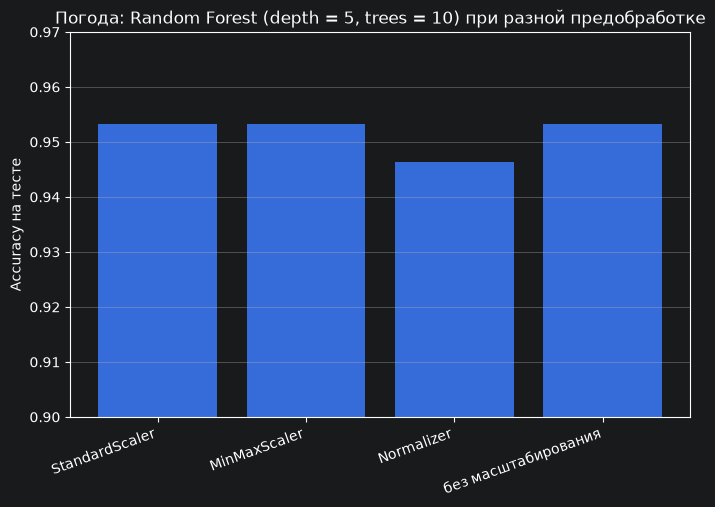

In [28]:
plt.figure(figsize=(8, 5))
tab = pd.DataFrame(rows_sc)
plt.bar(tab["Предобработка"], tab["Accuracy"])
plt.ylim(0.9, 0.97)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Accuracy на тесте")
plt.title("Погода: Random Forest (depth = 5, trees = 10) при разной предобработке")
plt.grid(True, axis="y")
plt.show()

`StandardScaler`, `MinMaxScaler` и вариант вообще без масштабирования дали **абсолютно одинаковый**
результат — Accuracy 0.9532 до четвёртого знака. Это ожидаемо: и стандартизация, и min-max — монотонные
преобразования каждого столбца по отдельности, они не меняют порядок значений внутри признака, а дерево
именно порядок и использует, когда подбирает порог разбиения. Пороги просто пересчитываются в новый
масштаб, а разбиение выборки остаётся тем же. То есть для деревьев и случайного леса масштабирование
не нужно вовсе (в отличие от k-NN из задания 3, где оно было критично).

Единственный, кто выбился, — `Normalizer` (0.9464, минус 0.7 п.п.). Он работает не по столбцам, а
**по строкам**: делит каждое наблюдение на его собственную норму. Из-за этого признаки перемешиваются
между собой — после такого преобразования «температура» строки зависит ещё и от давления в той же строке,
порядок значений внутри столбца ломается, и часть информации теряется. Так что `Normalizer` здесь
не нейтральное преобразование, а лёгкая порча данных.

## Часть 2. Чистка «грязного» датасета кафе

Модель здесь не обучаем — задание требует только предобработку: кодирование категорий, восполнение
пропусков, чистку от выбросов и дубликатов и приведение дат к единому формату.

### Шаг 1. Смотрим, что вообще лежит в данных

Прежде чем что-то чистить, полезно просто посмотреть `value_counts()` по каждому столбцу — так сразу видно
и настоящие категории, и мусор.

In [29]:
cafe = pd.read_csv("dirty_cafe_sales.csv")
print(cafe.shape)
cafe.head()

(10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [30]:
cafe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [31]:
for col in cafe.columns:
    print("---", col, "| уникальных:", cafe[col].nunique())
    print(cafe[col].value_counts(dropna=False).head(12))
    print()

--- Transaction ID | уникальных: 10000
Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
TXN_2602893    1
TXN_4433211    1
TXN_6699534    1
TXN_4717867    1
TXN_2064365    1
TXN_2548360    1
TXN_3051279    1
Name: count, dtype: int64

--- Item | уникальных: 10
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

--- Quantity | уникальных: 7
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64

--- Price Per Unit | уникальных: 8
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64

--- Total Spent | уникальных: 19
Total Spent
6.0     979

In [32]:
# запомним состояние «до», чтобы в конце сравнить
before = {"строк": len(cafe),
          "пропусков": int(cafe.isnull().sum().sum()),
          "полных дубликатов": int(cafe.duplicated().sum())}
before

{'строк': 10000, 'пропусков': 6826, 'полных дубликатов': 0}

Главная проблема видна сразу: **все столбцы прочитались как строки**, включая `Quantity`,
`Price Per Unit`, `Total Spent` и дату. Причина — мусорные значения `ERROR` и `UNKNOWN`, которые
разбросаны по всем столбцам. Формально `isnull()` показывает 6826 пропусков, но настоящих «дыр» больше:
`ERROR` и `UNKNOWN` pandas считает обычными строками, и если их не превратить в `NaN`, они молча уедут
в категории и в кодирование как полноценные значения.

`Transaction ID` уникален для всех 10000 строк, поэтому полных дубликатов ровно 0 — на дубликаты придётся
смотреть отдельно, без столбца с идентификатором.

### Шаг 2. Превращаем мусор в настоящие NaN и приводим типы

`ERROR` и `UNKNOWN` заменяем на `NaN`, числовые столбцы переводим в числа через `pd.to_numeric`
с `errors="coerce"` — всё, что не разобралось, тоже становится `NaN`.

In [33]:
c = cafe.replace(["ERROR", "UNKNOWN"], np.nan)

for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    c[col] = pd.to_numeric(c[col], errors="coerce")

print(c.dtypes)
print()
print("пропусков после замены мусора на NaN:")
print(c.isnull().sum())
print("всего:", int(c.isnull().sum().sum()))

Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
dtype: object

пропусков после замены мусора на NaN:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64
всего: 10082


Настоящих пропусков оказалось 10082 против 6826 «видимых» — то есть треть дыр была замаскирована
строками `ERROR` / `UNKNOWN`. Хуже всего заполнены `Location` (3961, почти 40%) и `Payment Method` (3178).

### Шаг 3. Восстанавливаем пропуски по смыслу данных

Прежде чем что-то удалять, стоит поискать в данных внутренние зависимости — тогда часть пропусков можно
восстановить точно, а не заполнять средним. Здесь их две.

In [34]:
# 1) проверяем соотношение Total Spent = Quantity * Price Per Unit
full = c.dropna(subset=["Quantity", "Price Per Unit", "Total Spent"])
mismatch = ((full["Total Spent"] - full["Quantity"] * full["Price Per Unit"]).abs() > 1e-6).sum()

print("строк, где известны все три числа:", len(full))
print("из них соотношение нарушено:", mismatch)

строк, где известны все три числа: 8544
из них соотношение нарушено: 0


In [35]:
# 2) цена, похоже, жёстко привязана к товару — проверяем
c.groupby("Item")["Price Per Unit"].agg(["nunique", "min", "max", "count"])

,nunique,min,max,count
Item,,,,
Cake,1,3.0,3.0,1085
Coffee,1,2.0,2.0,1108
Cookie,1,1.0,1.0,1026
Juice,1,3.0,3.0,1110
Salad,1,5.0,5.0,1082
Sandwich,1,4.0,4.0,1082
Smoothie,1,4.0,4.0,1036
Tea,1,1.5,1.5,1023


Обе догадки подтвердились: соотношение `Total Spent = Quantity × Price Per Unit` выполняется **точно во всех
8544 полных строках**, а у каждого товара ровно одна цена. Значит:

- цену можно восстановить по названию товара;
- любое одно пропущенное число из трёх восстанавливается по двум остальным;
- частично работает и обратный ход — если цена уникальна для товара (1.0 → Cookie, 1.5 → Tea, 2.0 → Coffee,
  5.0 → Salad), то по ней можно вернуть название. Для цен 3.0 (Cake / Juice) и 4.0 (Sandwich / Smoothie)
  это неоднозначно, так что такие строки останутся с пропуском.

In [36]:
price_by_item = {"Cookie": 1.0, "Tea": 1.5, "Coffee": 2.0, "Cake": 3.0,
                 "Juice": 3.0, "Sandwich": 4.0, "Smoothie": 4.0, "Salad": 5.0}
# обратное соответствие — только для цен, которые встречаются у одного товара
item_by_price = {1.0: "Cookie", 1.5: "Tea", 2.0: "Coffee", 5.0: "Salad"}

# цена из товара
c["Price Per Unit"] = c["Price Per Unit"].fillna(c["Item"].map(price_by_item))

# третье число из двух известных
m = c["Total Spent"].isna() & c["Quantity"].notna() & c["Price Per Unit"].notna()
c.loc[m, "Total Spent"] = c.loc[m, "Quantity"] * c.loc[m, "Price Per Unit"]

m = c["Quantity"].isna() & c["Total Spent"].notna() & c["Price Per Unit"].notna()
c.loc[m, "Quantity"] = c.loc[m, "Total Spent"] / c.loc[m, "Price Per Unit"]

m = c["Price Per Unit"].isna() & c["Total Spent"].notna() & c["Quantity"].notna()
c.loc[m, "Price Per Unit"] = c.loc[m, "Total Spent"] / c.loc[m, "Quantity"]

# товар из восстановленной цены, где она однозначна
c["Item"] = c["Item"].fillna(c["Price Per Unit"].map(item_by_price))

print("пропусков после восстановления:")
print(c.isnull().sum())

пропусков после восстановления:
Transaction ID         0
Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


Восстановление сработало очень хорошо: `Quantity` — с 479 пропусков до 23, `Price Per Unit` — с 533 до 6,
`Total Spent` — с 502 до 23, `Item` — с 969 до 480. Всё это точные значения, а не заполнение средним.

### Шаг 4. Приводим даты к единому формату

Даты лежат строками, среди них есть `ERROR`/`UNKNOWN` (уже стали `NaN`). Разбираем `pd.to_datetime`
с `errors="coerce"`, чтобы битые значения превратились в `NaT`, а не уронили разбор, и сразу вытаскиваем
из даты месяц, день недели и день месяца.

In [37]:
c["Transaction Date"] = pd.to_datetime(c["Transaction Date"], errors="coerce")

print("тип столбца:", c["Transaction Date"].dtype)
print("диапазон дат:", c["Transaction Date"].min().date(), "—", c["Transaction Date"].max().date())
print("не разобрано (NaT):", int(c["Transaction Date"].isna().sum()))

тип столбца: datetime64[us]
диапазон дат: 2023-01-01 — 2023-12-31
не разобрано (NaT): 460


In [38]:
c["Month"] = c["Transaction Date"].dt.month
c["Weekday"] = c["Transaction Date"].dt.dayofweek     # 0 — понедельник
c["Day"] = c["Transaction Date"].dt.day

c[["Transaction Date", "Month", "Weekday", "Day"]].head()

,Transaction Date,Month,Weekday,Day
0,2023-09-08,9.0,4.0,8.0
1,2023-05-16,5.0,1.0,16.0
2,2023-07-19,7.0,2.0,19.0
3,2023-04-27,4.0,3.0,27.0
4,2023-06-11,6.0,6.0,11.0


Все даты укладываются ровно в 2023 год (01.01 – 31.12), формат теперь единый `datetime64`. Не разобралось
460 значений — это те самые `ERROR` / `UNKNOWN`, восстановить дату транзакции нечем.

### Шаг 5. Что делать с оставшимися пропусками

Остатки очень разные по объёму, поэтому и решения разные:

- `Payment Method` (3178) и `Location` (3961) — это 32% и 40% выборки. Удалять столько строк нельзя, а
  заполнять модой значит выдумать способ оплаты для каждой третьей покупки и перекосить распределение.
  Поэтому «неизвестно» делаем **отдельной категорией** `Unknown` — при кодировании она получит свой код,
  и это честно отражает то, что в данных есть.
- `Item`, `Quantity`, `Price Per Unit`, `Total Spent` (480 и по паре десятков) и дата (460) — ключевые поля,
  восстановить их уже нечем. Строки с ними удаляем, это меньше 10% выборки.

In [39]:
c["Payment Method"] = c["Payment Method"].fillna("Unknown")
c["Location"] = c["Location"].fillna("Unknown")

c = c.dropna()

# строк с NaT больше нет, поэтому признаки из даты можно вернуть к целому типу
c[["Month", "Weekday", "Day"]] = c[["Month", "Weekday", "Day"]].astype(int)

print("строк осталось:", len(c))
print("пропусков осталось:", int(c.isnull().sum().sum()))

строк осталось: 9064
пропусков осталось: 0


### Шаг 6. Дубликаты и выбросы

In [40]:
print("полных дубликатов:", int(c.duplicated().sum()))
print("дубликатов, если не смотреть на Transaction ID:",
      int(c.drop(columns=["Transaction ID"]).duplicated().sum()))

c = c.drop_duplicates()
print("строк после drop_duplicates:", len(c))

полных дубликатов: 0
дубликатов, если не смотреть на Transaction ID: 234
строк после drop_duplicates: 9064


In [41]:
c[["Quantity", "Price Per Unit", "Total Spent"]].describe()

,Quantity,Price Per Unit,Total Spent
count,9064.000000,9064.000000,9064.000000
mean,3.018314,2.922165,8.830704
std,1.421799,1.300249,6.029576
min,1.000000,1.000000,1.000000
25%,2.000000,1.500000,4.000000
50%,3.000000,3.000000,7.500000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [42]:
# формальная проверка по правилу 1.5 * IQR
q1 = c["Total Spent"].quantile(0.25)
q3 = c["Total Spent"].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

print("границы IQR по Total Spent:", low, "—", high)
print("значений за границами:", int(((c["Total Spent"] < low) | (c["Total Spent"] > high)).sum()))
print()
print("максимум Total Spent:", c["Total Spent"].max(),
      "= максимум Quantity", c["Quantity"].max(), "* максимум цены", c["Price Per Unit"].max())

границы IQR по Total Spent: -8.0 — 24.0
значений за границами: 259

максимум Total Spent: 25.0 = максимум Quantity 5.0 * максимум цены 5.0


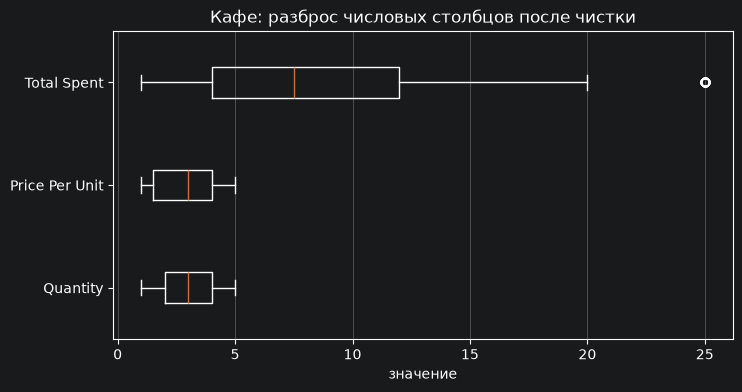

In [43]:
plt.figure(figsize=(8, 4))
plt.boxplot([c["Quantity"], c["Price Per Unit"], c["Total Spent"]],
            tick_labels=["Quantity", "Price Per Unit", "Total Spent"],
            orientation="horizontal")
plt.xlabel("значение")
plt.title("Кафе: разброс числовых столбцов после чистки")
plt.grid(True, axis="x")
plt.show()

**Дубликаты.** Полных дубликатов нет и быть не может — `Transaction ID` уникален. Без него совпадающих
строк 234, но это не ошибка данных: товаров всего 8, количество от 1 до 5, способов оплаты 4, мест 3
и дней в году 365, поэтому на 9 тысячах транзакций одинаковые чеки обязаны встречаться просто по теории
вероятностей. Удалять их означало бы стирать реальные покупки, поэтому оставляем.

**Выбросы.** Правило 1.5·IQR формально помечает 259 значений `Total Spent` (все со значением 25), но это
ложная тревога: `Quantity` не выходит за [1, 5], цена — за [1, 5], значит максимум чека 5 × 5 = 25 —
ровно то, что мы и видим. Никаких физически невозможных значений (отрицательных сумм, нулевого количества,
чеков в тысячи) после восстановления не осталось, так что настоящих выбросов в этом датасете нет.

### Шаг 7. Приводим категориальные значения к числовому виду

Три категориальных столбца — `Item`, `Payment Method`, `Location`. Кодируем `LabelEncoder`, отдельно по
каждому столбцу; исходные текстовые столбцы оставляем рядом, чтобы было видно соответствие.
`Transaction ID` не кодируем — это идентификатор, он уникален и как признак бесполезен.

In [44]:
for col in ["Item", "Payment Method", "Location"]:
    lab = LabelEncoder()
    c[col + " code"] = lab.fit_transform(c[col])
    print(col, "->", dict(zip(lab.classes_, range(len(lab.classes_)))))

Item -> {'Cake': 0, 'Coffee': 1, 'Cookie': 2, 'Juice': 3, 'Salad': 4, 'Sandwich': 5, 'Smoothie': 6, 'Tea': 7}
Payment Method -> {'Cash': 0, 'Credit Card': 1, 'Digital Wallet': 2, 'Unknown': 3}
Location -> {'In-store': 0, 'Takeaway': 1, 'Unknown': 2}


In [45]:
clean = c[["Transaction ID", "Item code", "Quantity", "Price Per Unit", "Total Spent",
           "Payment Method code", "Location code", "Transaction Date", "Month", "Weekday", "Day"]]
clean.head(10)

,Transaction ID,Item code,Quantity,Price Per Unit,Total Spent,Payment Method code,Location code,Transaction Date,Month,Weekday,Day
0,TXN_1961373,1,2.0,2.0,4.0,1,1,2023-09-08,9,4,8
1,TXN_4977031,0,4.0,3.0,12.0,0,0,2023-05-16,5,1,16
2,TXN_4271903,2,4.0,1.0,4.0,1,0,2023-07-19,7,2,19
3,TXN_7034554,4,2.0,5.0,10.0,3,2,2023-04-27,4,3,27
4,TXN_3160411,1,2.0,2.0,4.0,2,0,2023-06-11,6,6,11
5,TXN_2602893,6,5.0,4.0,20.0,1,2,2023-03-31,3,4,31
7,TXN_6699534,5,4.0,4.0,16.0,0,2,2023-10-28,10,5,28
9,TXN_2064365,5,5.0,4.0,20.0,3,0,2023-12-31,12,6,31
10,TXN_2548360,4,5.0,5.0,25.0,0,1,2023-11-07,11,1,7
12,TXN_7619095,5,2.0,4.0,8.0,0,0,2023-05-03,5,2,3


In [46]:
clean.info()

<class 'pandas.DataFrame'>
Index: 9064 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       9064 non-null   str           
 1   Item code            9064 non-null   int64         
 2   Quantity             9064 non-null   float64       
 3   Price Per Unit       9064 non-null   float64       
 4   Total Spent          9064 non-null   float64       
 5   Payment Method code  9064 non-null   int64         
 6   Location code        9064 non-null   int64         
 7   Transaction Date     9064 non-null   datetime64[us]
 8   Month                9064 non-null   int64         
 9   Weekday              9064 non-null   int64         
 10  Day                  9064 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(6), str(1)
memory usage: 849.8 KB


### Шаг 8. Сравнение «до / после» и что из данных теперь видно

In [47]:
after = {"строк": len(clean),
         "пропусков": int(clean.isnull().sum().sum()),
         "полных дубликатов": int(clean.duplicated().sum())}

pd.DataFrame([before, after], index=["до чистки", "после чистки"])

,строк,пропусков,полных дубликатов
до чистки,10000,6826,0
после чистки,9064,0,0


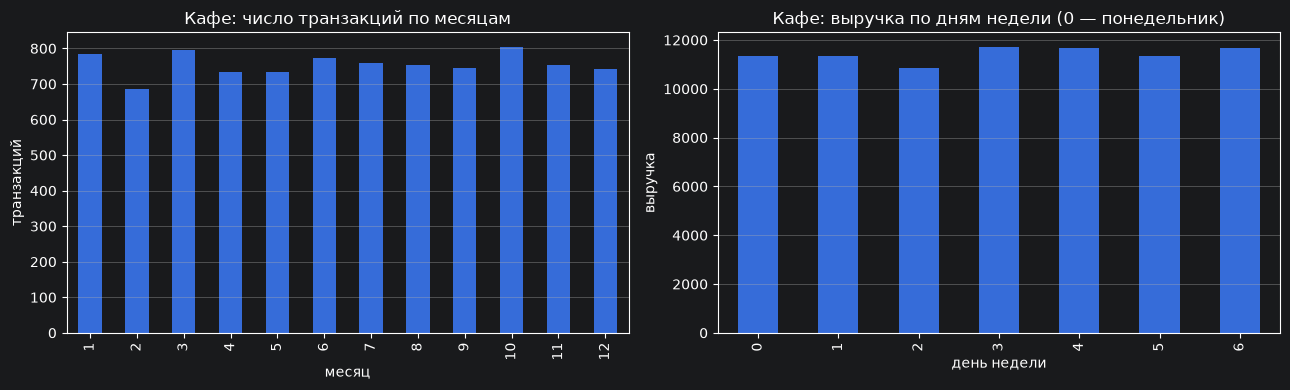

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

c["Month"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Кафе: число транзакций по месяцам")
axes[0].set_xlabel("месяц")
axes[0].set_ylabel("транзакций")
axes[0].grid(True, axis="y")

c.groupby("Weekday")["Total Spent"].sum().plot(kind="bar", ax=axes[1])
axes[1].set_title("Кафе: выручка по дням недели (0 — понедельник)")
axes[1].set_xlabel("день недели")
axes[1].set_ylabel("выручка")
axes[1].grid(True, axis="y")

fig.tight_layout()
plt.show()

In [49]:
# самые продаваемые товары и вклад в выручку
pd.DataFrame({"продано штук": c.groupby("Item")["Quantity"].sum(),
              "выручка": c.groupby("Item")["Total Spent"].sum()}).sort_values("выручка", ascending=False)

,продано штук,выручка
Item,,
Salad,3644.0,18220.0
Sandwich,3267.0,13068.0
Smoothie,3194.0,12776.0
Juice,3341.0,10023.0
Cake,3278.0,9834.0
Coffee,3766.0,7532.0
Tea,3441.0,5161.5
Cookie,3427.0,3427.0


Итог: из 10000 строк осталось 9064 (удалено 936, 9.4%), пропусков и дубликатов нет, все типы правильные —
числа числами, дата `datetime64`, категории кодами. Ключевым оказалось не заполнение пропусков средним,
а восстановление по внутренней зависимости `Total Spent = Quantity × Price Per Unit` и по жёсткой привязке
цены к товару: так удалось точно вернуть больше 1900 значений и удалить почти в четыре раза меньше строк,
чем пришлось бы иначе.

По самим данным закономерностей почти нет — датасет синтетический: транзакции распределены по месяцам
и дням недели практически равномерно (разница между месяцами в пределах случайного разброса), а выручка
по товарам определяется в основном их ценой, а не популярностью — `Salad` и `Sandwich` дают больше всех
при том, что штук продано у всех товаров примерно одинаково.

## Общий вывод

**Часть 1.** Датасет погоды выглядит чистым по `isnull()`, но содержит 11% строк с физически невозможными
значениями — их и надо было убирать, а не то, что помечает правило 1.5·IQR. После кодирования категорий,
отбора 7 признаков из 10 по feature importance и масштабирования без утечки все девять моделей Random Forest
дали 0.934–0.953 accuracy; лучшей оказалась `max_depth = 5`, `n_estimators = 10` (0.953). Глубина влияет
заметно сильнее числа деревьев, а единственная систематическая ошибка модели — путаница `Cloudy` / `Rainy`.
Сравнение трёх видов предобработки показало, что для леса `StandardScaler` и `MinMaxScaler` не меняют
результат вообще (деревья используют только порядок значений внутри признака), а `Normalizer` слегка
портит его, потому что нормирует строки, а не столбцы.

**Часть 2.** В датасете кафе главное — сначала превратить `ERROR` / `UNKNOWN` в настоящие `NaN` (иначе треть
пропусков останется незамеченной и уедет в категории), а потом искать не «чем заполнить», а «откуда точно
восстановить». Осталось 9064 строки из 10000 без пропусков и дубликатов, с датами в едином формате
`datetime64` и с вытащенными из них месяцем и днём недели.